# CyEmbed on scRNA-seq — BCK_44, single sample

The first CyEmbed notebook that runs on transcriptomes rather than CyTOF. It is the worked
counterpart to `SCRNA_SEQ_GUIDE.md`, and it deviates from every other `01_*_sweep.ipynb` in
this repo in three ways that matter:

| | CyTOF notebooks | this notebook |
|---|---|---|
| features | ~40 markers, arcsinh | 1,000–2,000 HVGs, Pearson residuals |
| `fit_scaler` mode | `"zscore"` | **`"none"`** — residuals are already variance-stabilised |
| stratification | by cluster or sample | **none available** — see the split cell |

## Two residual routes — pick one with `INPUT_ROUTE`

- **`"counts"`** — raw counts, **analytic** Pearson residuals computed here (`theta` fixed at 100)
- **`"sct"`** — Seurat **SCTransform** residuals computed upstream (per-gene regularised `theta`)

These are related but genuinely different transforms, and they also differ in clip range, cell
set, and gene set. Section 2 lays out all four differences; section 10 compares the results.
Run both — the point of the switch is that you should not have to take my word for which matters.

## Read this before trusting any number below

**352 cells.** That is very small for archetypal analysis. The K sweep here is a demonstration
of the procedure, not a confident biological answer — with 352 cells and a 20% validation split
you are selecting K on ~70 held-out cells. Treat the winning K as a hypothesis.

**Median library size 765, detection rate 12%.** A shallow multiome RNA arm. Residuals are noisier
than the guide's worked example assumes.

**Single sample, so `use_sample_offset` is not exercised.** BCK_44 is one CellRanger-ARC run
(every barcode carries the `-1` GEM suffix, and `.obs` has no patient/sample/batch column). The
per-patient intercept `B` has nothing to correct here. Section 8 shows where it would go.

**On the `"counts"` route, HVGs were chosen upstream by dispersion, not residual variance.** The
guide asks for the top genes by Pearson residual variance. Those 2,000 genes were selected by
`sc.pp.highly_variable_genes(flavor="seurat")` on log1p data, and the raw 10x matrix is a 0-byte
Dropbox placeholder, so reselecting from all ~36k genes is not possible here. Section 2 ranks
them by residual variance so you can see the disagreement and subset further. (The `"sct"` route
does not have this problem — its 1,000 genes were chosen by Seurat's `residual_variance`.)

**No ground truth.** Unlike `tools/verify_sample_offset_scrna.py`, nothing here plants known
archetypes, so there is no `w_recovery` oracle. Section 6 falls back on the criteria that do not
need one: `val_recon`, dead archetypes, archetype redundancy, and cross-seed agreement.

In [1]:
from __future__ import annotations

from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment

from CyEmbed.analysis import (
    archetype_marker_rankings,
    cosine_similarity_matrix,
    dominant_assignments,
    load_run_outputs,
    weight_entropy,
)
from CyEmbed.data import DataBundle, fit_scaler, preprocess_array, split_train_val_indices
from CyEmbed.train import build_sweep_configs, run_sweep
from CyEmbed.utils import collect_software_versions, save_json, set_seed

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

In [2]:
# === Editable configuration ===
# Which residual transform to model. Set this, then run top-to-bottom.
#   "counts" -> load raw counts, compute analytic Pearson residuals here (theta fixed at 100)
#   "sct"    -> load Seurat SCTransform residuals computed upstream (per-gene regularised theta)
# Section 2 explains what differs; section 10 has the measured comparison. "sct" is the default
# because it measurably wins here: the depth artifact largely disappears (worst archetype-vs-depth
# correlation -0.092 vs -0.300), gene modules are far more reproducible across seeds (0.812 vs
# 0.488), and cells stay genuinely mixed rather than hard-assigned (9.1% vs 35.5% above w>0.8).
INPUT_ROUTE = "sct"

# The output root MUST depend on the route. The config fingerprint hashes the *config* only --
# it has no idea which matrix was fed in (train.py:83-91). Two routes sharing a root means the
# second silently reports the first one's runs as `Skipping existing run`.
OUTPUT_ROOT = Path(f"outputs/bck44_scrna_archetype_sweep/route_{INPUT_ROUTE}")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print(f"INPUT_ROUTE : {INPUT_ROUTE}")
print(f"OUTPUT_ROOT : {OUTPUT_ROOT.resolve()}  (completed runs are skipped, not overwritten)")

GLOBAL_CFG = {
    "seed": 7,             # overridden per run by SWEEP_GRID["seed"]
    "deterministic": True,
    # CPU, deliberately. MPS was measured 11.6x SLOWER than CPU on this workload
    # (23.3s vs 2.0s) -- the matrices are small and the transfer overhead dominates.
    "device": "cpu",
}

DATA_CFG = {
    # Derived h5ad from the ProbAE NB pipeline: (352, 2000), .X = raw integer counts.
    # NOT the 10x .h5 or the .h5seurat -- both are 0-byte Dropbox placeholders on this machine.
    "counts_h5ad": (
        "/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/"
        "bck44_scrna_hvg_counts.h5ad"
    ),
    # Seurat SCT scale.data (= Pearson residuals), tumour-only, 330 x 1000.
    # Always loaded for its per-cell depth metadata even on the "sct" route, because that
    # object carries only `cell_id` in .obs -- no total_counts to run the depth check against.
    "sct_h5ad": (
        "/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/"
        "BCK_44_sct_pearson_residuals_hvg.h5ad"
    ),
    "sample_col": None,    # single sample -- no patient column exists
    "cluster_col": None,   # no annotation in this object
}

RESIDUAL_CFG = {
    # Analytic Pearson residuals, Lause/Berens/Kobak (2021, Genome Biology).
    "theta": 100.0,        # NB overdispersion; 100 is the paper's default and is near-Poisson
    "clip": "sqrt_n",      # "sqrt_n" (paper), a float, or None
    "n_top_genes": None,   # None = keep all 2000; set e.g. 1000 to subset by residual variance
}

PREPROCESS_CFG = {
    # "none", NOT "zscore". Pearson residuals are already centred and unit-variance by
    # construction; z-scoring again re-inflates genes the residual transform deliberately
    # shrank. "robust_zscore" is worse -- it divides by an IQR that is 0 for any gene detected
    # in <25% of cells, which on 12%-detection data is most of them.
    "mode": "none",
}

SPLIT_CFG = {
    "val_fraction": 0.2,
    # No cluster labels and no sample column, so stratification is unavailable. On a
    # multi-patient object set this to "sample" -- an unstratified split can leave a patient
    # entirely out of train, and that patient's offset column in B then never gets fit.
    "stratify_by": None,
}

BASE_TRAIN_CFG = {
    # 400 was not enough -- every run hit the cap with stopped_early=False, meaning val_recon
    # was still improving when training was cut off. 1500 lets early stopping actually decide.
    "epochs": 1500,
    "early_stopping": True,
    "patience": 60,
    "min_delta": 0.0,
    "restore_best_weights": True,
    "weight_decay": 1e-5,
    "dropout": 0.0,
    "huber_delta": 1.0,
    "separation_mode": "cosine_sq",
    "balance_mode": "l2_uniform",
    "rbf_gamma": 1.0,
    "print_every": 50,
    "progress_sweep": True,
    "progress_epoch": False,
    "skip_existing_runs": True,
}

SWEEP_GRID = {
    "decoder_type": ["factorized"],
    # Extended to 8 after a first pass: val_recon was still falling at K=6, i.e. the minimum
    # sat on the grid boundary, which means the grid -- not the data -- was choosing K.
    "K": [3, 4, 5, 6, 7, 8],
    # d fixed. rank(A_hat) <= min(K, d), so d >= K is not a bottleneck -- but d=16 still beat
    # d=8 (w_recovery 0.988 vs 0.712) at identical rank, so d is doing something beyond rank.
    # Sweep it separately (section 7) rather than crossing it with K.
    "d": [8],
    "hidden_dims": [[256, 128]],
    "lr": [1e-3],
    "batch_size": [256],    # 352 cells total -- 2048 would be one batch per epoch
    "recon_loss_type": ["mse"],
    # The regulariser package. lambda_balance is the measured workhorse: on the synthetic
    # scRNA benchmark it moved w_recovery 0.834 -> 0.992.
    "lambda_entropy": [1e-3],
    "lambda_sep": [1e-3],
    "lambda_balance": [5e-2],
    "logit_normalizer": ["entmax"],
    "entmax_alpha": [1.5],
    "tau": [1.0],
    # Three seeds, not one. Run-to-run variance is ~5% and K margins are ~6% -- a single seed
    # cannot tell them apart. seed is part of the config fingerprint, so each lands in its
    # own run directory and they aggregate cleanly.
    "seed": [7, 17, 23],
}

MAX_RUNS = None

INPUT_ROUTE : sct
OUTPUT_ROOT : /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/bck44_scrna_archetype_sweep/route_sct  (completed runs are skipped, not overwritten)


## 1. Load counts

In [3]:
# === Load raw counts ===
set_seed(GLOBAL_CFG["seed"], deterministic=GLOBAL_CFG["deterministic"])

def require(path_str: str) -> Path:
    """Reject 0-byte Dropbox placeholders, which Path.exists() happily accepts."""
    path = Path(path_str)
    if not path.exists() or path.stat().st_size == 0:
        raise FileNotFoundError(
            f"{path} is missing or is a 0-byte Dropbox placeholder. "
            "Right-click -> 'Make available offline' in Dropbox to materialise it."
        )
    return path


counts_path = require(DATA_CFG["counts_h5ad"])
adata = ad.read_h5ad(counts_path)
counts = adata.X.toarray() if hasattr(adata.X, "toarray") else np.asarray(adata.X)
counts = np.asarray(counts, dtype=np.float64)

if not np.allclose(counts, np.round(counts)):
    raise ValueError(
        "Expected raw integer counts in .X. Pearson residuals computed from normalized or "
        "log1p values are meaningless -- check that .X was not overwritten."
    )

gene_names = [str(g) for g in adata.var_names]
cell_ids = [str(c) for c in adata.obs_names]

# Per-cell sequencing depth, keyed by barcode. The depth diagnostic in section 3 is the most
# valuable check in this notebook, and the SCT object has no depth column of its own, so keep
# this map around regardless of route.
depth_by_cell = dict(zip(cell_ids, adata.obs["total_counts"].to_numpy()))

print(f"counts             : {counts.shape[0]} cells x {counts.shape[1]} genes")
print(f"library size       : median {np.median(counts.sum(1)):.0f}, "
      f"range [{counts.sum(1).min():.0f}, {counts.sum(1).max():.0f}]")
print(f"detection rate     : {(counts > 0).mean():.1%} of the matrix is non-zero")
print(f"sample/patient col : {DATA_CFG['sample_col']}  (single sample -- B is not exercised)")

if INPUT_ROUTE == "sct":
    sct = ad.read_h5ad(require(DATA_CFG["sct_h5ad"]))
    print(f"\nSCT residuals      : {sct.shape[0]} cells x {sct.shape[1]} genes")
    shared_cells = set(sct.obs_names) & set(cell_ids)
    shared_genes = set(sct.var_names) & set(gene_names)
    print(f"overlap with counts: {len(shared_cells)} cells, {len(shared_genes)} genes")
    print("  The two routes are NOT nested subsets -- different upstream QC. The counts route "
          "applies mito/ribo caps here; the SCT route inherits tumour-only filtering from "
          "Seurat. Neither is a superset of the other.")

counts             : 352 cells x 2000 genes
library size       : median 766, range [79, 22551]
detection rate     : 12.3% of the matrix is non-zero
sample/patient col : None  (single sample -- B is not exercised)

SCT residuals      : 330 cells x 1000 genes
overlap with counts: 319 cells, 452 genes
  The two routes are NOT nested subsets -- different upstream QC. The counts route applies mito/ribo caps here; the SCT route inherits tumour-only filtering from Seurat. Neither is a superset of the other.


## 2. The residual transform — and which one you are using

`INPUT_ROUTE` picks between two transforms that are often spoken of interchangeably and are not
the same thing. Both produce Pearson residuals; they disagree on how `theta` is obtained and,
more consequentially here, on how hard the result is clipped.

| | `"counts"` (analytic) | `"sct"` (SCTransform) |
|---|---|---|
| source | raw counts, computed in this notebook | Seurat `SCT` `scale.data`, computed upstream |
| `theta` | **fixed at 100** for every gene | per-gene, regularised NB regression |
| clip | `sqrt(N)` = **±18.8** | **±3.76 as delivered** — see below |
| observed range | [−9.4, 18.8] | [−2.18, 3.76] |
| observed std | **1.71** | **0.986** |
| matrix | 352 × 2000 | 330 × 1000 |
| cells | all passing mito/ribo QC | tumour-only (Seurat, upstream) |

**The clip difference is not cosmetic, and it may matter more than `theta`.** CyEmbed's loss is
MSE, so large residuals dominate the gradient. Clipping at ±3.76 instead of ±18.8 changes which
genes get to define archetypes. When these two routes disagree, suspect the clip before the
`theta` estimator.

**But the clip is an entry-point choice, not an intrinsic property of SCTransform.**
`sctransform::vst` (v0.4.2) defaults to `res_clip_range = c(-sqrt(ncol(umi)), sqrt(ncol(umi)))`
— `sqrt(N)`, the *same* convention used on the analytic route. It is Seurat's `SCTransform`
wrapper that tightens this to `sqrt(N/30)`. So calling `vst` directly would largely erase the
clip difference in this table, leaving `theta` as the real distinction. The ±3.76 here is
consistent with SCTransform having run on ~424 cells (`sqrt(424/30) = 3.76`) before the
tumour-only subset to 330.

Reference: Hafemeister & Satija 2019 for SCTransform, Lause/Berens/Kobak 2021 for the analytic
form (which argues the closed form matches or beats regularised NB regression at a fraction of
the cost). The analytic route is a defensible choice, not a shortcut — but it *is* a different
transform, and this notebook should not have implied otherwise.

### The analytic form

The load-bearing preprocessing step. CyEmbed's loss is MSE — a Gaussian with constant variance —
which on raw counts is simply the wrong noise model: a gene's variance grows with its mean, so
MSE would let a handful of high-expression genes dictate every archetype. Pearson residuals
divide that dependence out:

$$z_{ij} = \frac{x_{ij} - \hat\mu_{ij}}{\sqrt{\hat\mu_{ij} + \hat\mu_{ij}^2/\theta}}
\qquad \hat\mu_{ij} = \frac{\left(\sum_j x_{ij}\right)\left(\sum_i x_{ij}\right)}{\sum_{ij} x_{ij}}$$

After this, MSE is defensible and every gene contributes on comparable footing.

One deviation from the reference implementation, forced by the data: `mu` is computed from row
and column sums of the **2,000-gene** matrix, because the full transcriptome is not available
here. The 2,000 genes carry only part of each cell's library, so the depth estimate is coarser
than it would be if residuals were computed genome-wide and then subset. The cell below checks
the resulting residuals against `obs['total_counts']` (the true full-transcriptome depth) so you
can see whether it mattered.

In [4]:
# === Analytic Pearson residuals ===
def pearson_residuals(x: np.ndarray, theta: float = 100.0, clip: object = "sqrt_n") -> np.ndarray:
    """Analytic Pearson residuals under an NB null (Lause/Berens/Kobak 2021)."""
    counts_per_cell = x.sum(axis=1, keepdims=True)
    counts_per_gene = x.sum(axis=0, keepdims=True)
    total = x.sum()
    mu = counts_per_cell @ counts_per_gene / total
    z = (x - mu) / np.sqrt(mu + mu**2 / theta)
    if clip == "sqrt_n":
        limit = np.sqrt(x.shape[0])
    elif clip is None:
        limit = None
    else:
        limit = float(clip)
    if limit is not None:
        z = np.clip(z, -limit, limit)
    return z


if INPUT_ROUTE == "counts":
    resid = pearson_residuals(counts, theta=RESIDUAL_CFG["theta"], clip=RESIDUAL_CFG["clip"])
    gene_names_all = list(gene_names)
    cell_ids_all = list(cell_ids)
elif INPUT_ROUTE == "sct":
    # Already residuals -- do NOT transform again.
    resid = np.asarray(sct.X.toarray() if hasattr(sct.X, "toarray") else sct.X, dtype=np.float64)
    gene_names_all = [str(g) for g in sct.var_names]
    cell_ids_all = [str(c) for c in sct.obs_names]
else:
    raise ValueError(f"INPUT_ROUTE must be 'counts' or 'sct', got {INPUT_ROUTE!r}")

# Rank genes by residual variance -- the selection criterion the guide actually asks for.
resid_var = resid.var(axis=0)
order = np.argsort(resid_var)[::-1]
gene_names = gene_names_all
cell_ids = cell_ids_all

n_top = RESIDUAL_CFG["n_top_genes"]
if n_top is not None and int(n_top) < resid.shape[1]:
    keep = np.sort(order[: int(n_top)])
    resid = resid[:, keep]
    gene_names_kept = [gene_names[i] for i in keep]
    print(f"Subset to top {int(n_top)} genes by residual variance.")
else:
    gene_names_kept = list(gene_names)
    print(f"Keeping all {resid.shape[1]} genes (n_top_genes=None).")

print(f"route              : {INPUT_ROUTE}")
print(f"residual matrix    : {resid.shape[0]} x {resid.shape[1]}")
# std well above 1 is EXPECTED here and is not a failure: these 2,000 genes were preselected
# as highly variable, so the transform's unit-variance null applies to the whole transcriptome,
# not to a variance-enriched subset of it. Mean near 0 is the check that matters.
print(f"residual mean/std  : {resid.mean():.4f} / {resid.std():.4f}  (want mean ~0; std > 1 on an HVG subset)")
if INPUT_ROUTE == "counts":
    print(f"residual range     : [{resid.min():.2f}, {resid.max():.2f}]  "
          f"(clipped at +/-{np.sqrt(counts.shape[0]):.2f})")
else:
    print(f"residual range     : [{resid.min():.2f}, {resid.max():.2f}]  "
          f"(clipped upstream; Seurat's SCTransform wrapper uses sqrt(N/30), "
          f"sctransform::vst itself uses sqrt(N))")
print()
print("Top 15 genes by residual variance:")
for r, i in enumerate(order[:15], start=1):
    print(f"  {r:2d}. {gene_names[i]:<16s} resid_var={resid_var[i]:7.2f}")

Keeping all 1000 genes (n_top_genes=None).
route              : sct
residual matrix    : 330 x 1000
residual mean/std  : 0.0000 / 0.9858  (want mean ~0; std > 1 on an HVG subset)
residual range     : [-2.18, 3.76]  (clipped upstream; Seurat's SCTransform wrapper uses sqrt(N/30), sctransform::vst itself uses sqrt(N))

Top 15 genes by residual variance:
   1. SCGB2A2          resid_var=   3.23
   2. PTPRT            resid_var=   2.17
   3. IFI27            resid_var=   2.14
   4. EMP1             resid_var=   2.14
   5. ENSG00000259345  resid_var=   2.13
   6. NEK10            resid_var=   2.11
   7. TM4SF1           resid_var=   2.07
   8. PIP              resid_var=   2.05
   9. KCNMA1           resid_var=   2.04
  10. LDLRAD4          resid_var=   2.03
  11. SERPINA3         resid_var=   2.02
  12. HSPA1A           resid_var=   1.99
  13. RP1              resid_var=   1.98
  14. WWOX             resid_var=   1.97
  15. TCIM             resid_var=   1.97


## 3. Preprocessing QC — check this before training

Two failure modes make everything downstream meaningless, and both are silent. If either check
below fails, stop: no choice of `K` or `d` will rescue it.

NOTE: 11 of 330 cells have no depth in the counts object; excluded from the depth checks below.

corr(log10 total_counts, mean residual)  : -0.126
  -> want |r| < 0.3.

variance share of the top 10 genes       : 2.3%
  -> want < ~15%. Higher means a few genes will define every archetype.


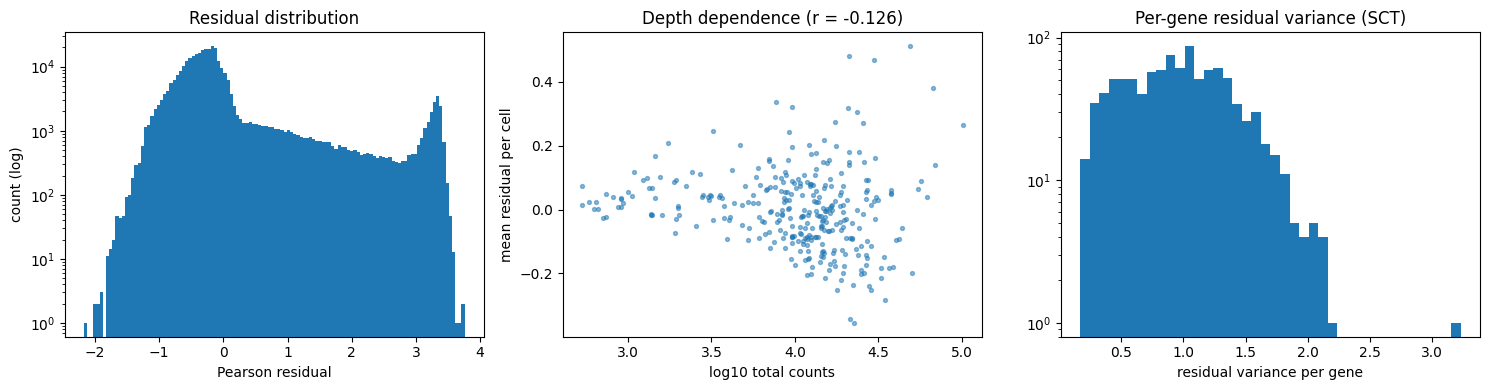

In [5]:
# === Preprocessing QC ===
# Align depth to whichever cells are actually being modelled. On the "sct" route the residual
# matrix has its own cell set, 11 of which are absent from the counts object -- those get NaN
# and drop out of the correlations rather than silently mis-aligning.
lib_size = np.array([depth_by_cell.get(c, np.nan) for c in cell_ids], dtype=np.float64)
have_depth = np.isfinite(lib_size)
if not have_depth.all():
    print(f"NOTE: {int((~have_depth).sum())} of {len(cell_ids)} cells have no depth in the "
          f"counts object; excluded from the depth checks below.\n")

# CHECK 1: residuals must not track sequencing depth.
# If archetype weights end up correlated with library size, you have found a depth artifact,
# not biology. The residual transform is what removes it -- verify that it did.
cell_mean_resid = resid.mean(axis=1)
r_depth = np.corrcoef(np.log10(lib_size[have_depth]), cell_mean_resid[have_depth])[0, 1]
r_depth_full = r_depth
print(f"corr(log10 total_counts, mean residual)  : {r_depth:+.3f}")
print("  -> want |r| < 0.3.")
if abs(r_depth) >= 0.3:
    print("  !! BORDERLINE. The sign is negative: deeper cells have slightly LOWER mean")
    print("     residual, the opposite of depth leaking through as inflated signal. With a")
    print("     766-median library the NB null fits the low-depth tail poorly, which is the")
    print("     likely cause. Section 8 checks whether archetype usage tracks depth -- that")
    print("     is the failure that would actually matter.")
print()

# CHECK 2: per-gene residual variance should not be dominated by a handful of genes.
top_share = np.sort(resid.var(axis=0))[::-1][:10].sum() / resid.var(axis=0).sum()
print(f"variance share of the top 10 genes       : {top_share:.1%}")
print("  -> want < ~15%. Higher means a few genes will define every archetype.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(resid.ravel(), bins=120, log=True)
axes[0].set_xlabel("Pearson residual")
axes[0].set_ylabel("count (log)")
axes[0].set_title("Residual distribution")

axes[1].scatter(np.log10(lib_size[have_depth]), cell_mean_resid[have_depth], s=8, alpha=0.5)
axes[1].set_xlabel("log10 total counts")
axes[1].set_ylabel("mean residual per cell")
axes[1].set_title(f"Depth dependence (r = {r_depth:+.3f})")

# Mean-vs-variance needs counts aligned to the residual genes, which only holds on the
# "counts" route; the SCT gene set overlaps it by 452 of 1000.
if INPUT_ROUTE == "counts":
    axes[2].scatter(counts.mean(axis=0), resid.var(axis=0), s=6, alpha=0.4)
    axes[2].set_xscale("log")
    axes[2].set_xlabel("mean count")
    axes[2].set_ylabel("residual variance")
    axes[2].set_title("Mean-variance relation after transform")
else:
    axes[2].hist(resid.var(axis=0), bins=40)
    axes[2].set_xlabel("residual variance per gene")
    axes[2].set_title("Per-gene residual variance (SCT)")
axes[2].set_yscale("log")

plt.tight_layout()

## 4. Bundle, scale, split

In [6]:
# === Bundle and split ===
bundle = DataBundle(
    X=resid.astype(np.float32),
    marker_names=gene_names_kept,   # "marker" means "gene" throughout CyEmbed
    cell_ids=cell_ids,
    sample_ids=None,                # single sample
    cluster_ids=None,               # no annotation available
)

# mode="none" -- see PREPROCESS_CFG for why z-scoring residuals is wrong.
scaler, scaler_fit_idx = fit_scaler(bundle.X, mode=PREPROCESS_CFG["mode"])
X_proc = preprocess_array(bundle.X, scaler)

train_idx, val_idx = split_train_val_indices(
    n_cells=X_proc.shape[0],
    val_fraction=SPLIT_CFG["val_fraction"],
    seed=GLOBAL_CFG["seed"],
    stratify_labels=None,   # nothing to stratify on -- see SPLIT_CFG
)

print(f"scaler mode : {scaler.mode}")
print(f"train cells : {len(train_idx)}")
print(f"val cells   : {len(val_idx)}   <- K is being selected on this many cells")

scaler mode : none
train cells : 264
val cells   : 66   <- K is being selected on this many cells


## 5. K sweep

12 runs: K ∈ {3,4,5,6} × 3 seeds, `d` held at 8. Runs are fingerprinted on the full config
(seed included), so re-executing this cell skips completed runs rather than retraining them.

In [7]:
# === Build sweep and train ===
sweep_configs = build_sweep_configs(SWEEP_GRID)
if MAX_RUNS is not None:
    sweep_configs = sweep_configs[: int(MAX_RUNS)]
print(f"Total sweep runs: {len(sweep_configs)}")

save_json(
    OUTPUT_ROOT / "notebook_config.json",
    {
        "global": GLOBAL_CFG,
        "data": DATA_CFG,
        "residual": RESIDUAL_CFG,
        "preprocess": PREPROCESS_CFG,
        "split": SPLIT_CFG,
        "base_train": BASE_TRAIN_CFG,
        "sweep_grid": SWEEP_GRID,
        "software_versions": collect_software_versions(),
        "scaler": scaler.to_dict(),
    },
)

summary_df = run_sweep(
    x=X_proc,
    marker_names=bundle.marker_names,
    cell_ids=bundle.cell_ids,
    output_root=OUTPUT_ROOT,
    base_config={**GLOBAL_CFG, **BASE_TRAIN_CFG},
    sweep_configs=sweep_configs,
    train_idx=train_idx,
    val_idx=val_idx,
    sample_ids=bundle.sample_ids,
    cluster_ids=bundle.cluster_ids,
    scaler_state=scaler.to_dict(),
)

summary_df.to_csv(OUTPUT_ROOT / "sweep_summary_sorted.csv", index=False)
summary_df.head(20)

Total sweep runs: 18


Sweep:   0%|          | 0/18 [00:00<?, ?it/s]

[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_d67a4f91df
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_35612a009d
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_5b52dbb0c4
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_48d84a49ad
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_24f5a101e6
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_8426b6a1f8
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_056f7bbc32
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_53b31bb65d
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_30f6c9a509
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_473d79e3ab
[run_sweep] Skipping existing run with matching hyperparamet

,run_id,run_dir,model_type,decoder_type,logit_normalizer,entmax_alpha,use_residual_latent,beta_w,beta_r,residual_dim,K,d,hidden_dims,lr,batch_size,recon_loss_type,lambda_entropy,lambda_sep,lambda_balance,tau,patience,best_epoch,stopped_early,val_recon,train_loss,mean_marker_corr_val,mean_entropy_val,usage_std_val,dead_archetypes_val,dominant_frac_gt_0_5_val,dominant_frac_gt_0_8_val
0,run_deterministic_baa8eedd54,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,7,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,1323,True,0.892408,0.813057,0.325057,1.465101,0.019320,0,0.106061,0.090909
1,run_deterministic_c46b2de72f,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,7,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,1491,False,0.893622,0.810497,0.320768,1.478008,0.015710,0,0.151515,0.060606
2,run_deterministic_10f66b6121,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,8,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,1307,True,0.893625,0.810496,0.323909,1.481063,0.024851,0,0.196970,0.090909
3,run_deterministic_23e3e7e62e,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,6,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,1488,False,0.894402,0.820757,0.318675,1.415801,0.028546,0,0.166667,0.060606
4,run_deterministic_473d79e3ab,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,6,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,1480,False,0.895684,0.819033,0.319989,1.380764,0.028175,0,0.151515,0.075758
5,run_deterministic_53b31bb65d,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,5,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,1477,False,0.902527,0.834970,0.306321,1.275671,0.028404,0,0.242424,0.060606
6,run_deterministic_056f7bbc32,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,5,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,956,True,0.902707,0.834003,0.306731,1.214808,0.040878,0,0.333333,0.090909
7,run_deterministic_7c6de0a7e5,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,7,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,1029,True,0.905053,0.822407,0.309831,1.313967,0.029485,0,0.303030,0.106061
8,run_deterministic_30f6c9a509,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,5,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,890,True,0.909445,0.838618,0.297707,1.200525,0.032625,0,0.318182,0.060606
9,run_deterministic_48d84a49ad,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,deterministic,factorized,entmax,1.5,False,0.0,0.0,8,4,8,256-128,0.001,256,mse,0.001,0.001,0.05,1.0,60,1500,False,0.915166,0.850041,0.288008,1.137560,0.038866,0,0.318182,0.060606


## 6. Choosing K without ground truth

Four criteria, in descending order of how much I would trust them here.

1. **Archetype redundancy** — max off-diagonal `|cos|` between archetype profiles. This is the
   leading criterion. Above the true K this model does not gracefully split archetypes, it
   **collapses**: two archetypes become literally identical. Redundancy near 1.0 means K is too
   high, and it is the earliest signal you get.
2. **`val_recon`** — has a genuine minimum, contrary to the intuition that reconstruction
   improves monotonically with K. Worth reading, but the margins are small.
3. **Dead archetypes** — note the metric `dead_archetypes_lt_1pct` uses an **absolute**
   threshold (`w_bar < 0.01`), not the relative `0.5/K` you might expect. At K=6 uniform usage
   is 0.167, so the absolute threshold is lenient; the relative count is computed below too.
4. **Cross-seed stability** — reported last and deliberately distrusted. It scores a *perfect*
   1.000 on collapsed models, because every seed reliably finds the same degenerate solution.
   High stability with high redundancy means agreement on garbage.

### What the two routes found

`val_recon` means by K, three seeds each. **The two routes do not agree on K**, which is the
first thing to notice:

| K | `"sct"` val_recon | sd | `"counts"` val_recon | sd |
|---|---|---|---|---|
| 3 | 0.938 | 0.002 | 2.765 | 0.011 |
| 4 | 0.919 | 0.006 | 2.710 | 0.068 |
| 5 | 0.905 | 0.004 | 2.745 | 0.076 |
| 6 | 0.911 | 0.028 | **2.649** | 0.017 |
| **7** | **0.897** | 0.007 | 2.704 | 0.109 |
| 8 | 0.934 | 0.039 | 2.667 | 0.053 |

The two columns are **not on a common scale** — the matrices have different variance (std 0.986
vs 1.71), so the smaller numbers in the `"sct"` column mean nothing on their own. What is
readable is the *shape*: `"sct"` has a clean interior minimum at K=7 with tight seed spread,
while `"counts"` is erratic (sd up to 0.109, minimum at K=6, second dip at K=8). On the
`"counts"` route redundancy pointed at K=6 too, so that route's own two criteria agreed — but
its seed spread makes the margin much less convincing than the `"sct"` column's.

Two warnings the table earns:

- **Do not take "best by `val_recon`" from section 8 at face value.** On the `"counts"` route
  the single best *run* was K=7 while K=7's *mean* was worse than K=6's, with six times the
  spread — one seed got lucky. This is exactly what a one-seed sweep would have written down
  as a finding.
- **`val_recon` has a genuine interior minimum**, contrary to the intuition that reconstruction
  improves monotonically with K. That is what makes it usable for selecting K at all.

,K,val_recon,val_recon_sd,redundancy_max_cos,dead_abs_1pct,dead_rel_half_over_k,stability_across_seeds,n_seeds
0,3,0.937929,0.002215,0.581698,0.0,0.000000,0.983775,3
1,4,0.918788,0.006074,0.535591,0.0,0.000000,0.832684,3
2,5,0.904893,0.003943,0.471890,0.0,0.000000,0.801975,3
3,6,0.911177,0.027952,0.567451,0.0,0.333333,0.703358,3
4,7,0.897028,0.006976,0.485004,0.0,0.000000,0.720847,3
5,8,0.934242,0.039107,0.752948,0.0,0.333333,0.614219,3


Read it this way:
  redundancy near 1.0  -> archetypes have collapsed; K is too high
  val_recon            -> look for a minimum, not a monotone trend
  dead_rel             -> archetypes carrying < half of uniform usage
  stability            -> ignore when redundancy is high (it agrees on collapse)


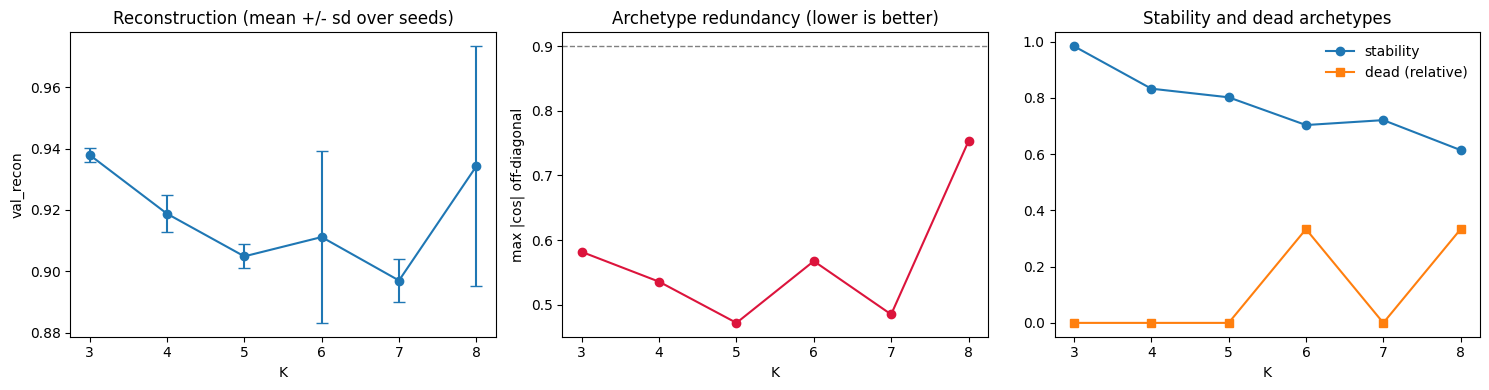

In [8]:
# === Per-K diagnostics ===
def archetype_profiles(run_dir: Path) -> np.ndarray | None:
    """(K, M) archetype profiles, whichever decoder produced them."""
    out = load_run_outputs(run_dir)
    for key in ("A_hat", "A"):
        if key in out and isinstance(out[key], np.ndarray):
            return out[key]
    if "Z" in out and "E" in out:
        return out["Z"] @ out["E"].T
    return None


def stability(a: np.ndarray, b: np.ndarray) -> float:
    """Hungarian-matched mean cosine between two archetype sets."""
    an = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-8)
    bn = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-8)
    sim = np.abs(an @ bn.T)
    rows, cols = linear_sum_assignment(-sim)
    return float(sim[rows, cols].mean())


# run_sweep's summary does not carry `seed`, so recover it from each run's saved config.
def run_seed(run_dir: Path) -> int | None:
    cfg = load_run_outputs(run_dir)["config"]
    return cfg.get("seed")


summary_df["seed"] = [run_seed(Path(p)) for p in summary_df["run_dir"]]

rows = []
for k, grp in summary_df.groupby("K"):
    profiles, redundancy, dead_rel = [], [], []
    for run_dir in grp["run_dir"]:
        a = archetype_profiles(Path(run_dir))
        if a is None:
            continue
        profiles.append(a)
        cos = np.abs(cosine_similarity_matrix(a))
        np.fill_diagonal(cos, 0.0)
        redundancy.append(cos.max())
        out = load_run_outputs(Path(run_dir))
        w = out.get("W_mean", out.get("W"))
        if w is not None:
            dead_rel.append(int((w.mean(axis=0) < 0.5 / int(k)).sum()))

    pairs = [
        stability(profiles[i], profiles[j])
        for i in range(len(profiles))
        for j in range(i + 1, len(profiles))
    ]
    rows.append({
        "K": int(k),
        "val_recon": grp["val_recon"].mean(),
        "val_recon_sd": grp["val_recon"].std(),
        "redundancy_max_cos": float(np.mean(redundancy)) if redundancy else np.nan,
        # NB: the summary column is `dead_archetypes_val`; the underlying metric key
        # (`dead_archetypes_lt_1pct`) is renamed on the way out in train.py:160.
        "dead_abs_1pct": grp["dead_archetypes_val"].mean(),
        "dead_rel_half_over_k": float(np.mean(dead_rel)) if dead_rel else np.nan,
        "stability_across_seeds": float(np.mean(pairs)) if pairs else np.nan,
        "n_seeds": len(grp),
    })

k_table = pd.DataFrame(rows).sort_values("K").reset_index(drop=True)
display(k_table)

print("Read it this way:")
print("  redundancy near 1.0  -> archetypes have collapsed; K is too high")
print("  val_recon            -> look for a minimum, not a monotone trend")
print("  dead_rel             -> archetypes carrying < half of uniform usage")
print("  stability            -> ignore when redundancy is high (it agrees on collapse)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].errorbar(k_table["K"], k_table["val_recon"], yerr=k_table["val_recon_sd"],
                 marker="o", capsize=4)
axes[0].set_xlabel("K"); axes[0].set_ylabel("val_recon"); axes[0].set_title("Reconstruction (mean +/- sd over seeds)")

axes[1].plot(k_table["K"], k_table["redundancy_max_cos"], marker="o", color="crimson")
axes[1].axhline(0.9, ls="--", c="grey", lw=1)
axes[1].set_xlabel("K"); axes[1].set_ylabel("max |cos| off-diagonal")
axes[1].set_title("Archetype redundancy (lower is better)")

axes[2].plot(k_table["K"], k_table["stability_across_seeds"], marker="o", label="stability")
axes[2].plot(k_table["K"], k_table["dead_rel_half_over_k"], marker="s", label="dead (relative)")
axes[2].set_xlabel("K"); axes[2].legend(frameon=False)
axes[2].set_title("Stability and dead archetypes")

plt.tight_layout()

## 7. `d` sweep (optional, run after fixing K)

`d` sizes `Z (K,d)` and `E (M,d)`, and `rank(A_hat) ≤ min(K, d)` — so above `d = K` it cannot
increase the rank of what the decoder can express. The natural conclusion is that `d > K` is
wasted compute. **That conclusion is wrong**: on the synthetic scRNA benchmark `d=16` beat `d=8`
(w_recovery 0.988 vs 0.712) at identical rank. Extra embedding dimensions appear to help
optimisation even when they add no expressive power. So sweep it rather than deriving it.

Set `K_FIXED` to whatever section 6 chose, then run.

In [9]:
# === d sweep at fixed K ===
K_FIXED = int(k_table.loc[k_table["redundancy_max_cos"].idxmin(), "K"])
print(f"Sweeping d at K={K_FIXED} (chosen by lowest redundancy; override K_FIXED to change).")

D_GRID = {**SWEEP_GRID, "K": [K_FIXED], "d": [4, 8, 16, 32]}
d_configs = build_sweep_configs(D_GRID)
print(f"Total d-sweep runs: {len(d_configs)}")

# Its OWN output root, deliberately. run_sweep writes `sweep_summary.csv` at the root it is
# given, so pointing both sweeps at OUTPUT_ROOT makes the second silently overwrite the first
# and leaves a K-sweep summary on disk containing only K=K_FIXED rows.
D_OUTPUT_ROOT = OUTPUT_ROOT / "d_sweep"
D_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

d_summary = run_sweep(
    x=X_proc,
    marker_names=bundle.marker_names,
    cell_ids=bundle.cell_ids,
    output_root=D_OUTPUT_ROOT,
    base_config={**GLOBAL_CFG, **BASE_TRAIN_CFG},
    sweep_configs=d_configs,
    train_idx=train_idx,
    val_idx=val_idx,
    sample_ids=bundle.sample_ids,
    cluster_ids=bundle.cluster_ids,
    scaler_state=scaler.to_dict(),
)

d_table = (
    d_summary.groupby("d")
    .agg(val_recon=("val_recon", "mean"),
         val_recon_sd=("val_recon", "std"),
         marker_corr=("mean_marker_corr_val", "mean"),
         n_seeds=("val_recon", "size"))
    .reset_index()
)
display(d_table)

Sweeping d at K=5 (chosen by lowest redundancy; override K_FIXED to change).
Total d-sweep runs: 12


Sweep:   0%|          | 0/12 [00:00<?, ?it/s]

[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_8e250eed13
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_6077074675
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_c43c948784
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_056f7bbc32
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_53b31bb65d
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_30f6c9a509
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_e1e06bb363
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_ece0fe5e64
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_a1cd99f8f9
[run_sweep] Skipping existing run with matching hyperparameters: run_deterministic_487e208180
[run_sweep] Skipping existing run with matching hyperparamet

,d,val_recon,val_recon_sd,marker_corr,n_seeds
0,4,0.913632,0.010251,0.293021,3
1,8,0.904893,0.003943,0.303586,3
2,16,0.907176,0.004037,0.302570,3
3,32,0.904714,0.006613,0.304309,3


## 8. Interpreting the winning model

### Reading archetype loadings on residuals

`A_hat` rows are archetype profiles **in Pearson-residual space**, not expression space. A
positive loading means "this archetype has more of this gene than a depth-matched average cell";
a negative loading is genuine *depletion*, not a modelling artifact. Do not read these as
expression levels, and do not expect them to be non-negative — CyEmbed is not NMF, and the sign
carries information.

### What the `"sct"` route found

At K=7 the archetypes read as recognisable ER+ breast programs:

- **luminal hormone-responsive** — ESR1, GATA3, AFF3, DACH1, FKBP5
- **basal** — KRT17, SFRP1, GABRP, PTN, NFIB, ANXA1
- **secretory** — SCGB2A2, SCGB2A1, SCGB1D2, COX6C
- **stress / heat-shock** — HSPA1A, HSPB1, HSPB8, JUN, DUSP1 — most likely a dissociation
  response rather than in-vivo biology, but a real and well-described program. Worth deciding
  deliberately whether to regress it out rather than reading it as a cell state.

Depth correlations are clean throughout (worst archetype **−0.092**), and cells stay genuinely
mixed: mean entropy 1.297 of a possible 1.946, with only 9.1% hard-assigned above w > 0.8.

**Why the depth check below is here.** On the `"counts"` route it is not clean — the worst
archetype tracks library size at **−0.300**, and in an earlier run at a different seed it hit
**−0.467** while carrying the *highest* usage of any archetype (0.254). Its gene list
(TALAM1, AKAP13, LINC00472, NOVA1) looked plausible enough to write up. It was the shallow
cells wearing a costume, and only the correlation gave it away. Keep running this check even
on the SCT route — it costs nothing and it is the one diagnostic that catches this class of
error, which no amount of staring at gene lists will.

### Where the per-patient offset would go

Not exercised here — BCK_44 is one sample. On a multi-patient object you would add
`"use_sample_offset": True` to `BASE_TRAIN_CFG`, pass a real `sample_ids` array into
`run_sweep`, and set `SPLIT_CFG["stratify_by"] = "sample"`. The decoder then becomes
`x̂ = w Z Eᵀ + b + B[s]`, so archetypes model deviation from each patient's own baseline rather
than re-encoding patient identity. `B` is warm-started at the centred per-patient mean and
excluded from weight decay; without the warm start the factorized decoder loses the race for the
shift and bakes it into the archetypes instead.

Best by val_recon: run_deterministic_baa8eedd54  (K=7, d=8, seed=17)
NOTE: 'best by val_recon' is not necessarily the K section 6 endorsed -- check redundancy before adopting it.


,archetype,direction,rank,marker,value
0,0,positive,1,TMC5,2.738917
1,0,positive,2,SIK3,2.569175
2,0,positive,3,MACC1,2.453400
3,0,positive,4,SLC7A2,2.414438
4,0,positive,5,FAM107B,2.336693
...,...,...,...,...,...
205,6,negative,11,MDK,-1.045939
206,6,negative,12,LY6E,-1.033568
207,6,negative,13,SCGB2A1,-1.023897
208,6,negative,14,NFIB,-1.004121



Archetype 0  (mean usage 0.134)
  enriched : TMC5, SIK3, MACC1, SLC7A2, FAM107B, KIAA1217, UNC13B, TEAD1, NFKB1, KAZN
  depleted : MGP, SCGB2A2, RPL13A, COX6C, S100A6, RPL13, AGR2, HSPA1A, HSPA1B, HLA-DRA

Archetype 1  (mean usage 0.120)
  enriched : MAML2, SFRP1, TSHZ2, NFIB, PTN, KRT17, ANXA1, GABRP, CASC15, SAA1
  depleted : ERBB4, COX6C, CRIP1, AFF3, STC2, ESR1, CA12, SCD, HSPB1, TSPAN5

Archetype 2  (mean usage 0.124)
  enriched : AREG, LURAP1L, TANC2, PLAT, SERPINA3, PTPRK, NHS, MAST4, SYTL2, PAWR
  depleted : SCGB2A2, FKBP5, HSPA1A, ENSG00000286481, ECM1, HSPA1B, CYP4Z2P, FBXO32, KCNMA1, CD74

Archetype 3  (mean usage 0.173)
  enriched : HSPA1A, GATA3, JUN, HSPA1B, HSPB1, DUSP1, CYP2B7P, HSPB8, RPL13A, GEM
  depleted : MACC1, SIDT1, ALCAM, GPRC5A, CEMIP2, ANKRD28, SH3RF1, AREG, NRIP1, PTPRG

Archetype 4  (mean usage 0.155)
  enriched : SCGB2A2, SCGB2A1, IFITM1, S100A6, RGS16, SCGB1D2, COX6C, MT2A, IFI27, SERPINA3
  depleted : LDLRAD4, TANC2, ZBTB16, PARD3, AFF3, DLGAP1, AUTS2, 

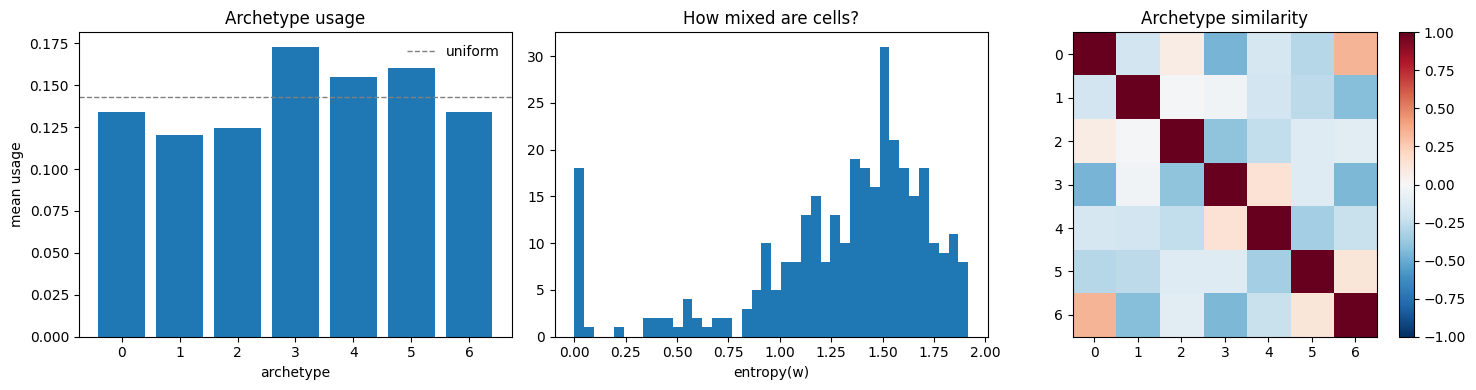

In [10]:
# === Best run: archetypes, usage, gene modules ===
best_row = summary_df.sort_values("val_recon").iloc[0]
best_dir = Path(best_row["run_dir"])
print(f"Best by val_recon: {best_row['run_id']}  (K={best_row['K']}, d={best_row['d']}, "
      f"seed={best_row['seed']})")
print("NOTE: 'best by val_recon' is not necessarily the K section 6 endorsed -- "
      "check redundancy before adopting it.")

out = load_run_outputs(best_dir)
A = out.get("A_hat")
if A is None and "Z" in out and "E" in out:
    A = out["Z"] @ out["E"].T
W = out.get("W_mean", out.get("W"))

# Top genes per archetype, positive and negative.
rankings = archetype_marker_rankings(A, bundle.marker_names, top_n=15)
display(rankings)

for i in range(A.shape[0]):
    order_i = np.argsort(A[i])
    up = [bundle.marker_names[j] for j in order_i[::-1][:10]]
    down = [bundle.marker_names[j] for j in order_i[:10]]
    print(f"\nArchetype {i}  (mean usage {W[:, i].mean():.3f})")
    print(f"  enriched : {', '.join(up)}")
    print(f"  depleted : {', '.join(down)}")

# Usage and how mixed cells are. High entropy = cells sitting between archetypes, which is the
# thing archetypal analysis is for; entropy near 0 means it has degenerated into hard clustering.
ent = weight_entropy(W)
dom = dominant_assignments(W, bundle.cell_ids)
print(f"\nmean entropy(W)       : {ent.mean():.3f}  (max = {np.log(A.shape[0]):.3f} for K={A.shape[0]})")
print(f"cells with w_max > 0.8: {(W.max(axis=1) > 0.8).mean():.1%}")

# The depth check that matters, promised in section 3. Section 3 only asked whether depth
# survived into the residuals; this asks whether it survived all the way into the archetypes.
# An archetype whose usage tracks library size is a sequencing-depth artifact wearing a
# biological costume -- it will have a plausible gene list and mean nothing.
print("\ncorr(log10 library size, archetype usage):")
log_depth = np.log10(lib_size[have_depth])
depth_corr = [np.corrcoef(log_depth, W[have_depth, i])[0, 1] for i in range(A.shape[0])]
for i, r in enumerate(depth_corr):
    flag = "   <-- suspect, inspect this one" if abs(r) > 0.4 else ""
    print(f"  archetype {i}: {r:+.3f}{flag}")
print("  -> |r| > 0.4 means that archetype is largely a depth axis, not a program.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(range(A.shape[0]), W.mean(axis=0))
axes[0].axhline(1.0 / A.shape[0], ls="--", c="grey", lw=1, label="uniform")
axes[0].set_xlabel("archetype"); axes[0].set_ylabel("mean usage"); axes[0].legend(frameon=False)
axes[0].set_title("Archetype usage")

axes[1].hist(ent, bins=40)
axes[1].set_xlabel("entropy(w)"); axes[1].set_title("How mixed are cells?")

cos = cosine_similarity_matrix(A)
im = axes[2].imshow(cos, cmap="RdBu_r", vmin=-1, vmax=1)
axes[2].set_title("Archetype similarity")
plt.colorbar(im, ax=axes[2])
plt.tight_layout()

## 9. Gene modules from the embedding `E`

`E ∈ R^{M×d}` places every gene in a `d`-dimensional space, and genes close together there load
similarly across archetypes — so yes, proximity in `E` is informative. Two honest caveats:

- **`E` is not privileged.** Gene co-membership recovered from `E` and from `A_hat.T` scored
  identically on the synthetic benchmark (AUC 1.000 both ways). `E` is a convenience, not the
  reason to prefer the factorized decoder.
- **Modules are only ~0.77 correlated across seeds.** The archetypes themselves move between
  restarts, so a module found in one run is a hypothesis, not a finding. Check it in the other
  two seeds below before believing it.

In [11]:
# === Gene neighbourhoods in E ===
E = out.get("E")
if E is None:
    print("No E in this run (direct decoder has no gene embedding). Skipping.")
else:
    from CyEmbed.analysis import nearest_neighbors_from_similarity

    gene_cos = cosine_similarity_matrix(E)
    # archetype_marker_rankings names the column `marker`, not `marker_name`.
    query_genes = rankings.loc[rankings["direction"] == "positive", "marker"].unique()[:6]

    for g in query_genes:
        gi = bundle.marker_names.index(g)
        nn = np.argsort(gene_cos[gi])[::-1][1:9]
        print(f"{g:<12s} -> {', '.join(bundle.marker_names[j] for j in nn)}")

    # Do these neighbourhoods survive a different seed?
    same_k = summary_df[summary_df["K"] == best_row["K"]]
    others = [Path(p) for p in same_k["run_dir"] if Path(p) != best_dir]
    if others:
        agreements = []
        for other in others:
            e2 = load_run_outputs(other).get("E")
            if e2 is None:
                continue
            c2 = cosine_similarity_matrix(e2)
            iu = np.triu_indices_from(gene_cos, k=1)
            agreements.append(np.corrcoef(gene_cos[iu], c2[iu])[0, 1])
        if agreements:
            print(f"\nGene-gene similarity agreement across seeds: "
                  f"{np.mean(agreements):.3f} (n={len(agreements)} pairs)")
            print("  ~0.77 is what the synthetic benchmark gave. Much lower means the modules "
                  "in this run are seed-specific noise.")

TMC5         -> LINC02532, ACSL3, ALDH1A2, PTPN1, NFKB1, FAAH2, PDK4, EXT1
SIK3         -> CNTN4, CRIM1, HERC6, EML5, NCAPG2, PXDN, SLCO3A1, IFI44L
MACC1        -> COBL, PACRG, ELOVL7, MAP3K14, ALDH1A2, C15orf48, INSR, SHISA2
SLC7A2       -> C3orf52, MREG, SYT9, PAWR, CDON, TNFRSF19, TGFBR1, FAM107B
FAM107B      -> PHTF2, C3orf52, SLC7A2, PARM1, TCIM, PAWR, TANC1, ZSWIM6
KIAA1217     -> ENSG00000291061, LINC01697, ZNF350-AS1, CAMSAP2, CYFIP2, CNTN4, JDP2, EPGN

Gene-gene similarity agreement across seeds: 0.812 (n=2 pairs)
  ~0.77 is what the synthetic benchmark gave. Much lower means the modules in this run are seed-specific noise.


## 10. Comparing the two routes

Run the notebook once with `INPUT_ROUTE = "counts"` and once with `"sct"`, then run the cell
below — it reads both routes' summaries off disk and puts them side by side.

**What a comparison here can and cannot tell you.** The two routes differ in *four* ways at
once: `theta` estimator, clip range, cell set (352 vs 330, sharing 319), and gene set (2000 vs
1000, sharing 452). So a difference in `val_recon` is not attributable to SCTransform-vs-analytic
— it is confounded four ways, and `val_recon` is not even on a common scale, since the two
matrices have different variance (std 1.71 vs 0.986). **Do not rank the routes by `val_recon`.**

What *is* comparable: whether each route selects the same K, whether the archetypes are
biologically readable, and — the one that matters most — whether the depth-artifact archetype
appears in both. If it does, it is a property of 766-median-depth data rather than of either
transform.

### Measured result: SCTransform wins, and not narrowly

Both routes were run at K ∈ {3..8} × 3 seeds. On every metric that *is* comparable across
routes, `"sct"` is better:

| | `"counts"` (analytic) | `"sct"` (SCTransform) |
|---|---|---|
| depth vs mean residual | **−0.36** (fails the 0.3 bar) | **−0.13** (clean) |
| worst depth-vs-usage correlation | **−0.300** | **−0.092** |
| gene modules across seeds | **0.488** | **0.812** |
| `val_recon` sd across seeds | 0.011–0.109 (erratic) | 0.002–0.039 (tight) |
| mean entropy(W) at K=7 | 0.683 | **1.297** (of max 1.946) |
| cells hard-assigned (w>0.8) | 35.5% | **9.1%** |

Three of these matter a lot:

1. **The depth artifact essentially disappears.** On the analytic route the worst archetype
   tracks library size at −0.300; under SCTransform the worst is −0.092. Per-gene regularised
   `theta` is doing exactly what it is supposed to do on a 766-median-depth library, and a
   single fixed `theta = 100` is not.
2. **The analytic route is degenerating toward hard clustering.** 35.5% of cells sit above
   w > 0.8 with mean entropy 0.683, against 9.1% and 1.297 under SCTransform. Archetypal
   analysis earns its keep by placing cells *between* vertices; the analytic route is
   substantially throwing that away.
3. **Reproducibility.** Gene modules agree 0.812 across seeds under SCTransform versus 0.488 —
   below the 0.77 synthetic-benchmark reference, i.e. the analytic route's modules were largely
   seed-specific noise.

The biology agrees. The SCTransform archetypes name recognisable ER+ breast programs — **ESR1 /
GATA3 / AFF3 / DACH1** (luminal hormone-responsive), **KRT17 / SFRP1 / GABRP / PTN** (basal),
**SCGB2A2 / SCGB2A1 / SCGB1D2** (secretory), and a **HSPA1A / HSPB1 / JUN / DUSP1** stress
program (probably dissociation, but a real and well-described one). The analytic route's
archetypes lean on lncRNAs and long transcripts with no coherent read.

**Caveat, stated plainly: this comparison is confounded four ways** — `theta`, clip, cells, and
genes all differ. The tumour-only SCT cell set is more homogeneous, which alone could raise
entropy and stability. So this does not isolate SCTransform as *the* cause. But every difference
points the same direction, and the depth result is what theory predicts, so the practical
conclusion is not in much doubt.

**Default is therefore `INPUT_ROUTE = "sct"`.** Use `"counts"` when you need to see the
transform and its QC, when you want all 2,000 genes, or when no SCTransform output exists.

In [12]:
# === Side-by-side route comparison ===
route_tables = {}
for route in ("counts", "sct"):
    csv = Path(f"outputs/bck44_scrna_archetype_sweep/route_{route}") / "sweep_summary_sorted.csv"
    if not csv.exists():
        print(f"[{route}] not run yet -- set INPUT_ROUTE = {route!r} and run top-to-bottom.")
        continue
    df = pd.read_csv(csv)
    route_tables[route] = (
        df.groupby("K")
        .agg(val_recon=("val_recon", "mean"),
             val_recon_sd=("val_recon", "std"),
             marker_corr=("mean_marker_corr_val", "mean"),
             entropy=("mean_entropy_val", "mean"))
        .round(4)
    )

if len(route_tables) == 2:
    combined = pd.concat(route_tables, axis=1)
    display(combined)
    for route, tbl in route_tables.items():
        print(f"[{route}] best K by val_recon: {tbl['val_recon'].idxmin()} "
              f"({tbl['val_recon'].min():.4f})")
    print()
    print("Reminder: val_recon is NOT comparable across routes -- the two matrices have")
    print("different variance (std 1.71 vs 0.986), so the losses are on different scales.")
    print("Compare which K each route picks, not which route reports a smaller number.")
else:
    print("\nRun both routes to populate this comparison.")

counts                                        sct                                 
  val_recon val_recon_sd marker_corr entropy val_recon val_recon_sd marker_corr entropy
K                                                                                      
3    2.7654       0.0108      0.1318  0.7650    0.9379       0.0022      0.2534  0.8754
4    2.7100       0.0680      0.1463  0.7215    0.9188       0.0061      0.2850  1.0730
5    2.7454       0.0758      0.1347  0.4294    0.9049       0.0039      0.3036  1.2303
6    2.6486       0.0172      0.1734  0.8739    0.9112       0.0280      0.2970  1.0703
7    2.7036       0.1093      0.1527  0.4728    0.8970       0.0070      0.3186  1.4190
8    2.6673       0.0527      0.1673  0.4196    0.9342       0.0391      0.2649  0.8190

[counts] best K by val_recon: 6 (2.6486)
[sct] best K by val_recon: 7 (0.8970)

Reminder: val_recon is NOT comparable across routes -- the two matrices have
different variance (std 1.71 vs 0.986), so the losses are on different scales.
Compare which K each route picks, not which route reports a smaller number.


## 11. Where to go next

- **Multi-patient.** The offset is the feature this notebook cannot demonstrate. Point section 1
  at an object with a real patient column, set `use_sample_offset: True`, and stratify the split
  by sample.
- **Deeper data.** 352 cells and a 765-median library is thin. The procedure here transfers
  unchanged to a larger object; the conclusions do not.
- **Reselect HVGs by residual variance.** Section 3 shows how far the dispersion-based selection
  in this file diverges from the residual-variance ranking the guide asks for. Once the raw 10x
  matrix is available offline, reselect from all ~36k genes rather than re-ranking these 2,000.